In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("Customer Churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [11]:
#replacing blanks with zero as when the Tenure is 0 the Total Charges are blank & converting datatype to float
data['TotalCharges'] = data['TotalCharges'].replace(" ","0")
data['TotalCharges'] = data['TotalCharges'].astype("float")
data.dtypes                                                    

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [14]:
#descriptive analysis of dataset
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
#checks for duplicate values in the dataset
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [24]:
#function to convert value of senoir citizen column from 0/1 to yes/no for better understanding
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
data['SeniorCitizen'] = data['SeniorCitizen'].apply(conv)

In [27]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


FINDING HOW MANY CUSTOMERS HAVE CHURNED OUT AND HOW MANY ARE STILL HERE

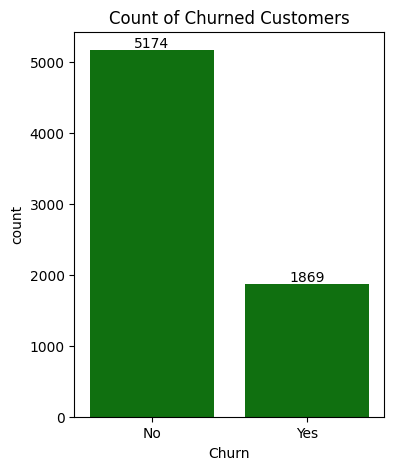

In [8]:
plt.figure(figsize=(4,5))
ax=sns.countplot(x='Churn',data=data,color="green")
ax.bar_label(ax.containers[0])
plt.title("Count of Churned Customers")
plt.show()

In [40]:
df = data.groupby('Churn').size()
df

Churn
No     5174
Yes    1869
dtype: int64

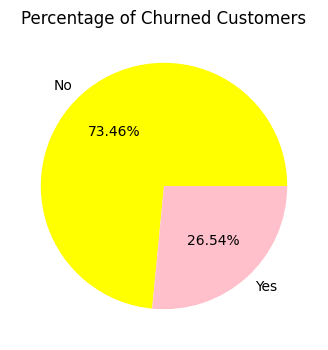

In [49]:
plt.figure(figsize=(4,4))
plt.pie(df.values,labels=df.index,autopct="%1.2f%%",colors=["yellow","pink"])
plt.title("Percentage of Churned Customers")
plt.show()

#The % of Churned out People is less than the People who have stayed

In [ ]:
GENDER WISE CHURNED ANALYSIS

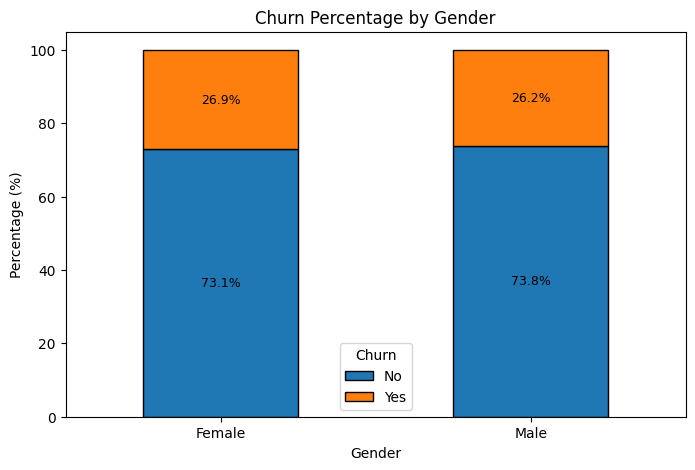

In [33]:
import matplotlib.pyplot as plt

# Count data
stack_data = data.groupby(['gender', 'Churn']).size().unstack()

# Convert counts to percentages
percent_data = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

# Plot
ax = percent_data.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    edgecolor='black'
)

plt.title("Churn Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)  # x-axis labels vertically

# ---- Add Percentage Labels ----
for i, (index, row) in enumerate(percent_data.iterrows()):
    cum = 0
    for val in row:
        if val > 0:
            ax.text(
                i, 
                cum + (val / 2),
                f"{val:.1f}%",     # percentage label
                ha='center',
                va='center',
                fontsize=9
            )
        cum += val

plt.legend(title="Churn")
plt.show()



#There Slight diffrence in Male vs Female Churned out Data

SENIOR CITIZEN CHURNED ANALYSIS

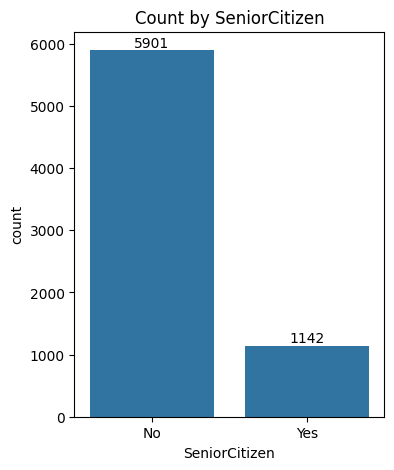

In [13]:
plt.figure(figsize=(4,5))
ax=sns.countplot(x='SeniorCitizen',data=data)
ax.bar_label(ax.containers[0])
plt.title("Count by SeniorCitizen")
plt.xticks(ticks=[0,1], labels=['No', 'Yes'])
plt.show()

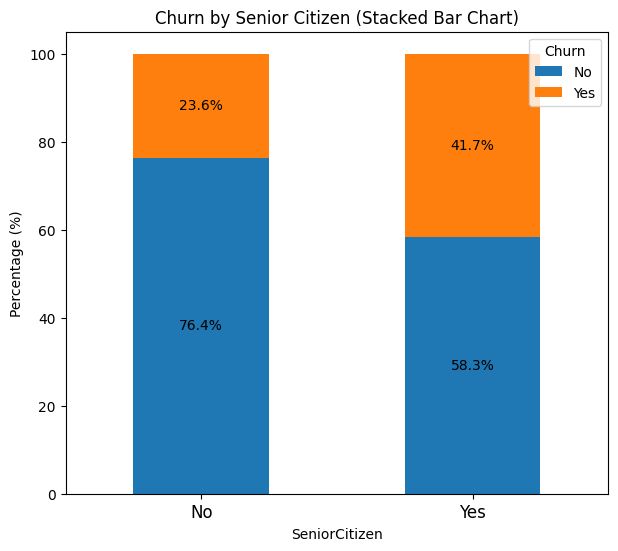

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Percentage calculation
total_counts = data.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(7, 6))  # Bada figure for clarity
total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])

# Add percentage labels
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f"{height:.1f}%", ha='center', va='center')

# Customize axes
plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0,1], labels=['No', 'Yes'], rotation=0, fontsize=12)  # Horizontal, readable
plt.legend(title='Churn', loc='upper right')

plt.show()




#Senior citizen People have the high percentage of churned out then Young People

TENURE WISE CHURN DATA

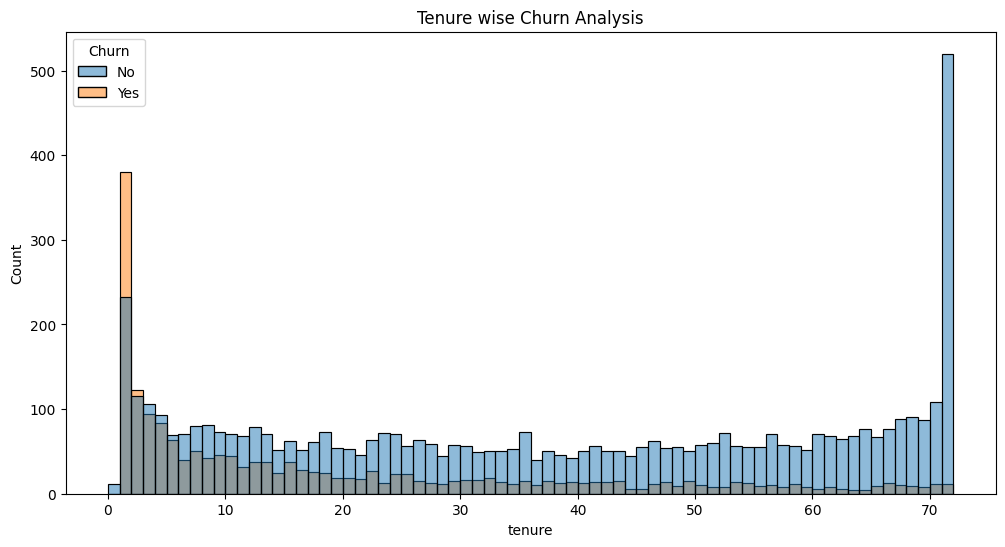

In [34]:
plt.figure(figsize=(12,6))
sns.histplot(x='tenure',data=data,edgecolor='black',bins=72,hue="Churn")
plt.title('Tenure wise Churn Analysis')
plt.show()

#People who have used the services for a ling time have stayed and those who use the services for a short period have churned

In [ ]:
CONTRACT WISE CHURN ANALYSIS

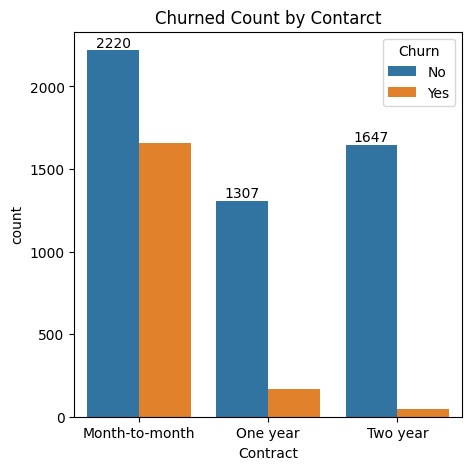

In [59]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x='Contract',data=data,hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Churned Count by Contarct")
plt.show()

#People who have month-to-month contract are likely to churn then people who have 1 or 2 years of contract

In [ ]:
CHRUN ANALYSIS BY ADDITIONAL SERVICES

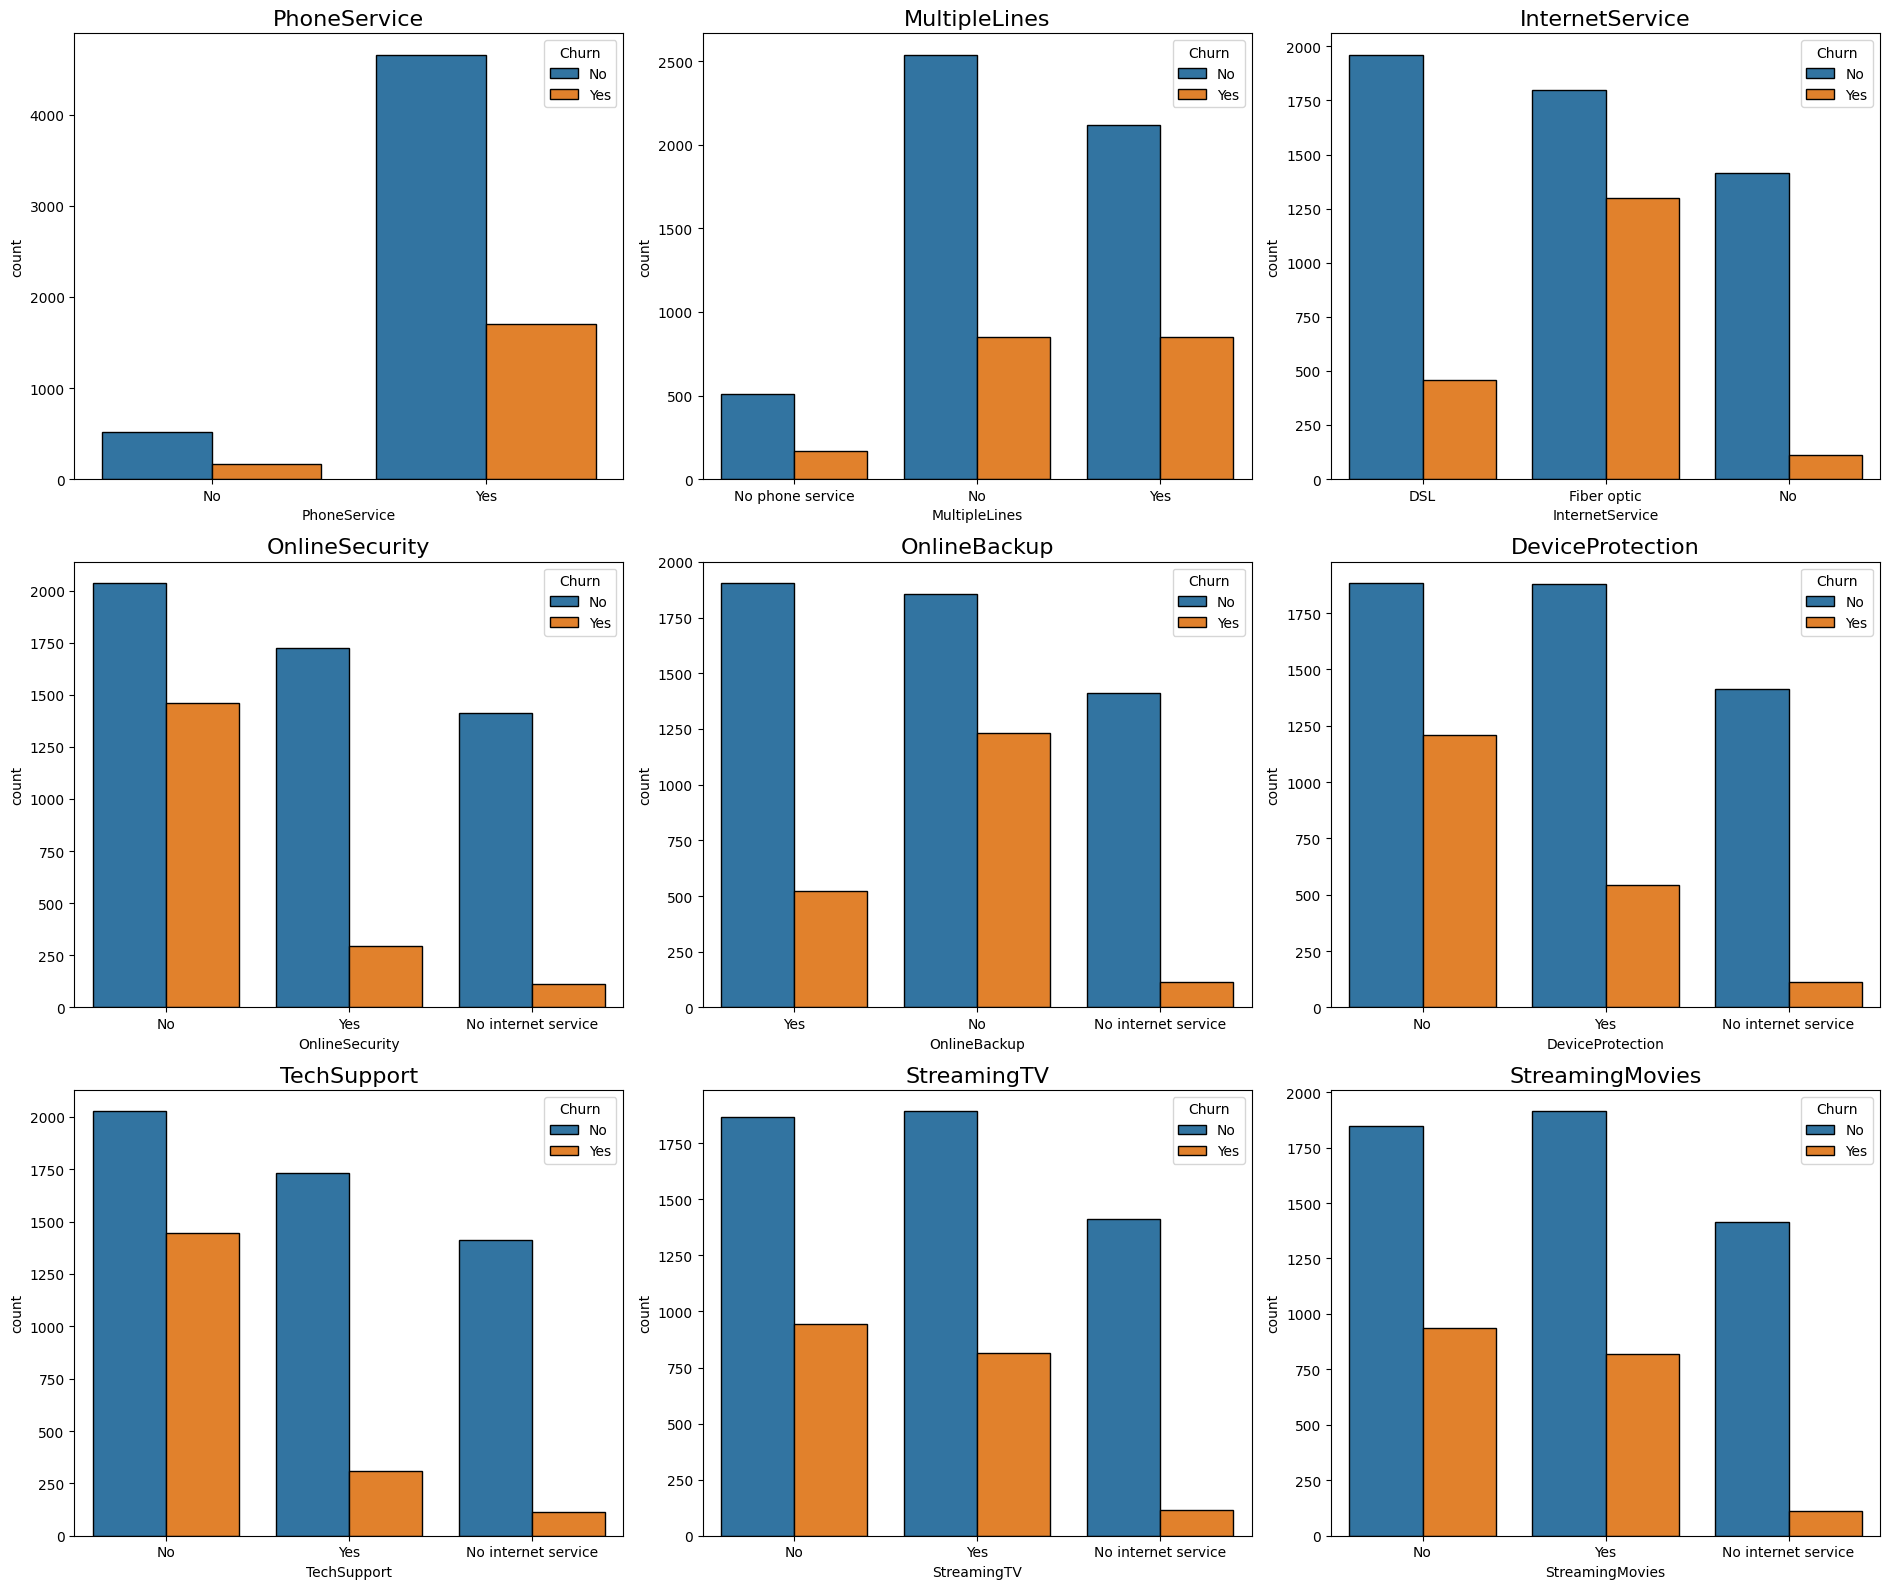

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

plt.figure(figsize=(19, 16))   # Bigger figure

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=data, x=col, edgecolor='black',hue=data['Churn'])
    plt.title(col,fontsize=16)
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


#Customers with fiber optic internet also show high churn, indicating possible service dissatisfaction.
Overall, churn is significantly higher among users who don’t subscribe to additional protection, backup, or streaming services, showing these add-on services help retain customers.

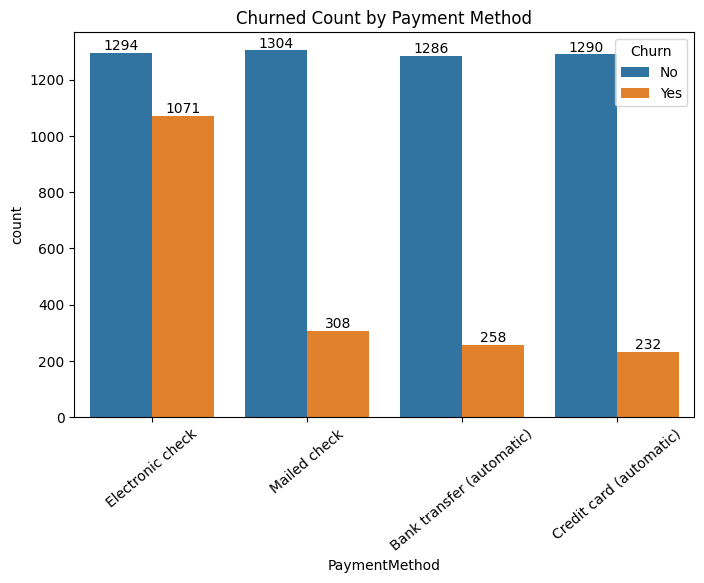

In [65]:
plt.figure(figsize=(8,5))
ax=sns.countplot(x='PaymentMethod',data=data,hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Count by Payment Method")
plt.xticks(rotation=40)
plt.show()

#People who uses Electronic check as Payment option are most likely to churn